# 03 - Modelado predictivo

## Objetivo
Evaluar la capacidad de prediccion de `stress_level` bajo dos configuraciones metodologicas:

1. **Escenario A (`cleaned_data`)**: utiliza el dataset limpio general.
2. **Escenario B (`model_ready`)**: utiliza un dataset preparado para modelado, excluyendo variables excesivamente cercanas al objetivo.

La comparacion entre ambos escenarios permite analizar si el desempeno del modelo se sostiene con predictores mas realistas para un contexto aplicado.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.modeling import run_modeling, plot_confusion_matrices

In [2]:
# Escenario A: dataset limpio general
model_out_original = run_modeling(
    processed_file=ROOT / "data" / "processed" / "cleaned_data.csv"
)

# Escenario B: dataset preparado para modelado
model_out_no_leak = run_modeling(
    processed_file=ROOT / "data" / "processed" / "model_ready.csv"
)

print("Target detectado:", model_out_original["target_col"])
print("\nColumnas excluidas por alta cercania con la variable objetivo (Escenario A):")
print(model_out_original["leakage_columns_removed"])

print("\nColumnas excluidas por alta cercania con la variable objetivo (Escenario B):")
print(model_out_no_leak["leakage_columns_removed"])

print("\nMetricas del escenario A (dataset limpio general):")
display(model_out_original["scores_original"])

print("\nMetricas del escenario B (dataset model_ready):")
display(model_out_no_leak["scores_original"])

print("\nComparacion consolidada entre escenarios:")
comparison_table = pd.concat(
    {
        "escenario_A_cleaned": model_out_original["scores_original"],
        "escenario_B_model_ready": model_out_no_leak["scores_original"],
    }
)
display(comparison_table)

Target detectado: stress_level

Columnas excluidas por alta cercania con la variable objetivo (Escenario A):
['anxiety_level', 'addiction_level']

Columnas excluidas por alta cercania con la variable objetivo (Escenario B):
[]

Metricas del escenario A (dataset limpio general):


,accuracy,precision,recall,f1,cv_accuracy_mean,cv_f1_weighted_mean,cv_precision_weighted_mean,cv_recall_weighted_mean
Logistic Regression,0.316667,0.316612,0.316667,0.312325,0.355833,0.352000,0.357211,0.355833
Random Forest,0.300000,0.298945,0.300000,0.298327,0.341667,0.341337,0.342611,0.341667



Metricas del escenario B (dataset model_ready):


,accuracy,precision,recall,f1,cv_accuracy_mean,cv_f1_weighted_mean,cv_precision_weighted_mean,cv_recall_weighted_mean
Random Forest,0.333333,0.335381,0.333333,0.332956,0.358333,0.357095,0.357413,0.358333
Logistic Regression,0.312500,0.311377,0.312500,0.309558,0.370000,0.366524,0.373776,0.370000



Comparacion consolidada entre escenarios:


accuracy  precision    recall  \
escenario_A_cleaned     Logistic Regression  0.316667   0.316612  0.316667   
                        Random Forest        0.300000   0.298945  0.300000   
escenario_B_model_ready Random Forest        0.333333   0.335381  0.333333   
                        Logistic Regression  0.312500   0.311377  0.312500   

                                                   f1  cv_accuracy_mean  \
escenario_A_cleaned     Logistic Regression  0.312325          0.355833   
                        Random Forest        0.298327          0.341667   
escenario_B_model_ready Random Forest        0.332956          0.358333   
                        Logistic Regression  0.309558          0.370000   

                                             cv_f1_weighted_mean  \
escenario_A_cleaned     Logistic Regression             0.352000   
                        Random Forest                   0.341337   
escenario_B_model_ready Random Forest                   0.357095   
                        Logistic Regression             0.366524   

                                             cv_precision_weighted_mean  \
escenario_A_cleaned     Logistic Regression                    0.357211   
                        Random Forest                          0.342611   
escenario_B_model_ready Random Forest                          0.357413   
                        Logistic Regression                    0.373776   

                                             cv_recall_weighted_mean  
escenario_A_cleaned     Logistic Regression                 0.355833  
                        Random Forest                       0.341667  
escenario_B_model_ready Random Forest                       0.358333  
                        Logistic Regression                 0.370000

Matrices de confusion - Escenario A (cleaned_data)


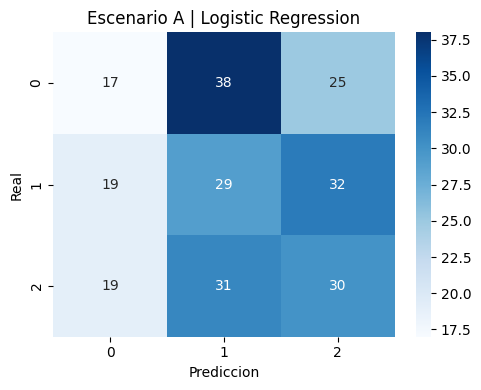

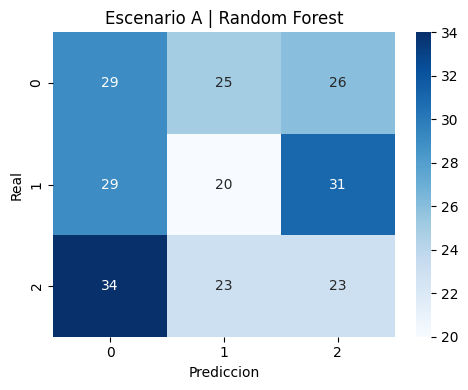

Matrices de confusion - Escenario B (model_ready)


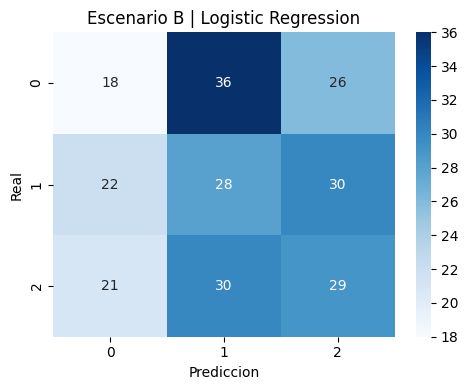

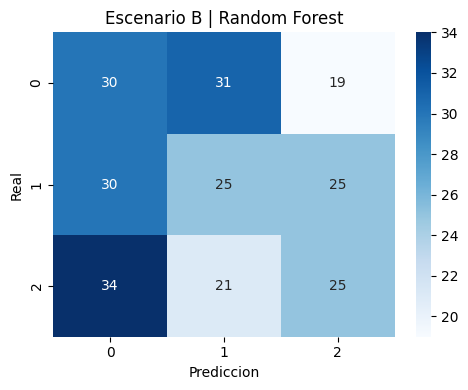

Top 10 variables mas influyentes - Random Forest (Escenario B)


,feature,importance
4,num__academic_performance,0.126467
10,num__wellbeing_risk_score,0.120407
1,num__daily_social_media_hours,0.109809
2,num__sleep_hours,0.106750
5,num__physical_activity,0.099694
3,num__screen_time_before_sleep,0.094387
0,num__age,0.070924
15,cat__platform_usage_tiktok,0.021044
16,cat__social_interaction_level_high,0.020630
14,cat__platform_usage_instagram,0.020486


In [3]:
print("Matrices de confusion - Escenario A (cleaned_data)")
plot_confusion_matrices(model_out_original["results_original"], title_prefix="Escenario A | ")

print("Matrices de confusion - Escenario B (model_ready)")
plot_confusion_matrices(model_out_no_leak["results_original"], title_prefix="Escenario B | ")

print("Top 10 variables mas influyentes - Random Forest (Escenario B)")
model_out_no_leak["feature_importance_top20_original"].head(10)

## Criterios de interpretacion

La evaluacion del modelo se presenta con enfoque de informe academico:

- **Metricas de desempeno:** se comparan `accuracy`, `f1` y resultados de validacion cruzada para medir calidad y estabilidad.
- **Matrices de confusion:** se revisa la distribucion de aciertos y errores por nivel de estres.
- **Importancia de variables:** se identifican los predictores con mayor aporte al modelo, priorizando habitos digitales y estilo de vida.

La comparacion entre escenarios permite sustentar la respuesta a la pregunta de investigacion con evidencia cuantitativa verificable.

In [4]:
# Comparacion directa de F1 por modelo (Escenario B - Escenario A)
comparison = model_out_no_leak["scores_original"]["f1"] - model_out_original["scores_original"]["f1"]
comparison = comparison.to_frame(name="delta_f1_escenario_B_vs_A")
comparison

,delta_f1_escenario_B_vs_A
Logistic Regression,-0.002768
Random Forest,0.034630
